<a href="https://colab.research.google.com/github/Zheleikina/NM/blob/main/%D0%9B%D0%A0_13_%D0%96%D0%B5%D0%BB%D0%B5%D0%B9%D0%BA%D1%96%D0%BD%D0%B0_%D0%927.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 13.

Желейкіна Аліна. Варіант 7.

#Метод Ейлера

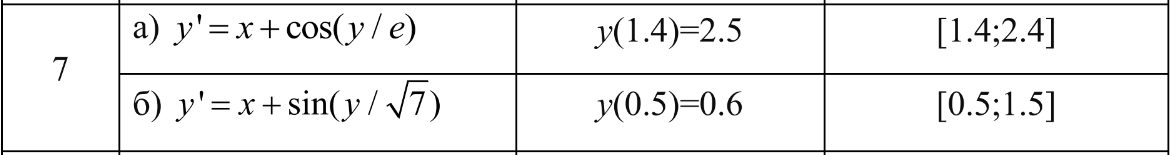

x = [1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4] 
y = [2.5    2.7006 2.9052 3.1133 3.3246 3.5387 3.7552 3.9741 4.1949 4.4177
 4.6422]


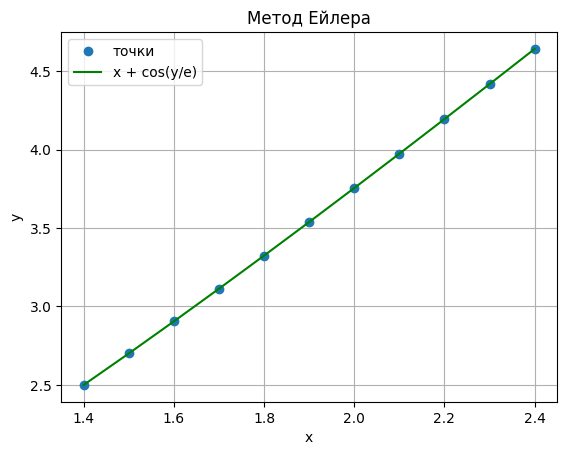

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return x + np.cos(y/ np.exp(1))

# Вводимо параметри (ліва, права межі відрізку, крок, початкова умова)
a, b, h, y0 = 1.4, 2.4, 0.1, 2.5

# Перевірка вхідних параметрів
if h <= 0:
    print("Крок h повинен бути позитивним.")
    exit()
if a >= b:
    print("Права межа b повинна бути більшою за ліву межу a.")
    exit()

n = int((b - a) / h) # кількість кроків

x = np.array([a + i*h for i in range(n + 1)]) # задаємо x генератором списків

y = np.empty(n + 1)
y[0] = y0

for i in range(n):
    y[i + 1] = y[i] + f(x[i], y[i]) * h

y_rounded = np.round(y, 4)
print("x =", x, "\ny =", y_rounded)

plt.plot(x, y, "o", x, y, "green")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Метод Ейлера")
plt.legend(["точки", "x + cos(y/e)"])
plt.grid()
plt.show()

In [ ]:
#Додати перевірку odeint для першого завдання


x= [1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4]
y= [2.5        2.70259694 2.9088891  3.11847171 3.33097829 3.54608619
 3.7635211  3.98306076 4.20453734 4.42783931 4.65291247]


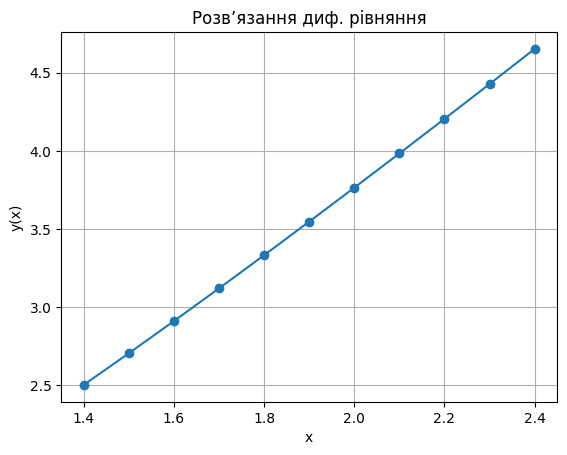

In [16]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Функція, що повертає dy/dx
def model(y, x):
    return x + np.cos(y/ np.exp(1))

# Початкова умова
y0 = 2.5

# Значення x
a = 1.4
b = 2.4
h = 0.1
x = np.array([a + i * h for i in range(int((b - a) / h) + 1)])

# Розв'язання ODE
y = odeint(model, y0, x)

# Виведення результатів
print('x=', x)
print('y=', y.flatten())  # Перетворення в одновимірний масив для виводу

# Побудова графіка результатів
plt.plot(x, y, marker='o')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Розв’язання диф. рівняння')
plt.grid()
plt.show()

In [ ]:
#додати перевірку solve_ivp для перешого завдання

x= [1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4]
y= [2.5        2.70259688 2.90889575 3.11848755 3.33099621 3.54609857
 3.76352439 3.98305635 4.20453005 4.42783402 4.65290969]


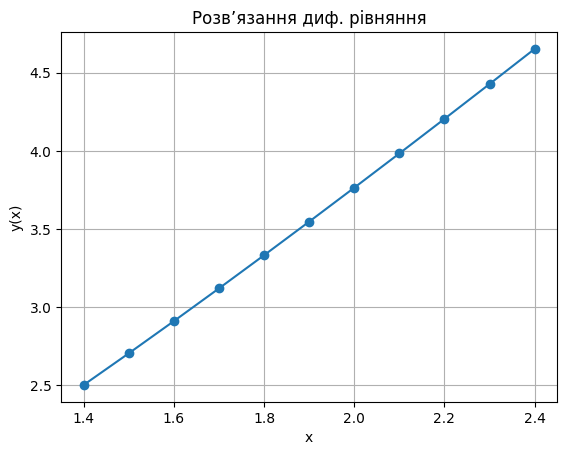

In [17]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Функція, що повертає dy/dx
def model(x, y):
    return x + np.cos(y/ np.exp(1))

# Початкова умова
y0 = [2.5]  # Потрібно передати як список

# Межі інтегрування та крок
a = 1.4
b = 2.4
h = 0.1
x = np.array([a + i * h for i in range(int((b - a)/h) + 1)])

# Розв'язання ODE
sol = solve_ivp(model, [x[0], x[-1]], y0, t_eval=x)

# Виведення результатів
print('x=', sol.t)
print('y=', sol.y[0])

# Побудова графіка результатів
plt.plot(sol.t, sol.y[0], marker='o')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Розв’язання диф. рівняння')
plt.grid()
plt.show()

#Метод Ейлера-Коші

x = [0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5] 
y = [0.6    0.6912 0.7977 0.92   1.0588 1.2146 1.3876 1.5779 1.7851 2.0088
 2.2477]


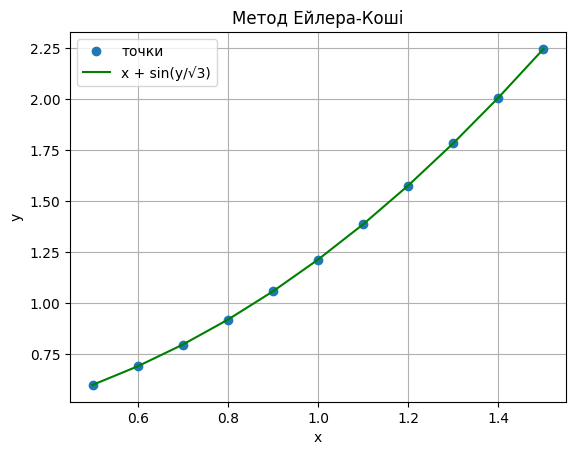

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return x + np.sin(y/ np.sqrt(3))

a = 0.5  # ліва межа відрізку
b = 1.5  # права межа відрізку
h = 0.1  # крок
y0 = 0.6  # початкова умова
n = int((b - a) / h)  # кількість кроків

# Генерація x, враховуючи останнє значення
x = np.arange(a, b + h, h)  # Задати x з включенням b

y = np.empty(n + 1)
y[0] = y0

# Метод Ейлера-Коші
for i in range(n):
    # Використовується середнє значення для нахилу
    y[i + 1] = y[i] + (f(x[i], y[i]) + f(x[i + 1], y[i] + h * f(x[i], y[i]))) * h / 2

y_rounded = np.round(y, 4)

print("x =", x, "\ny =", y_rounded)

# Візуалізація
plt.plot(x, y, "o", x, y, "green")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Метод Ейлера-Коші")
plt.legend(["точки", "x + sin(y/√3)"])
plt.grid()
plt.show()


#Розв’язок диф. Рівняння за допомогою scipy.integrate import odeint

x= [0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5]
y= [0.6        0.69134963 0.79795512 0.92047363 1.05948623 1.21545236
 1.38865426 1.57913222 1.78661674 2.01046407 2.2496071 ]


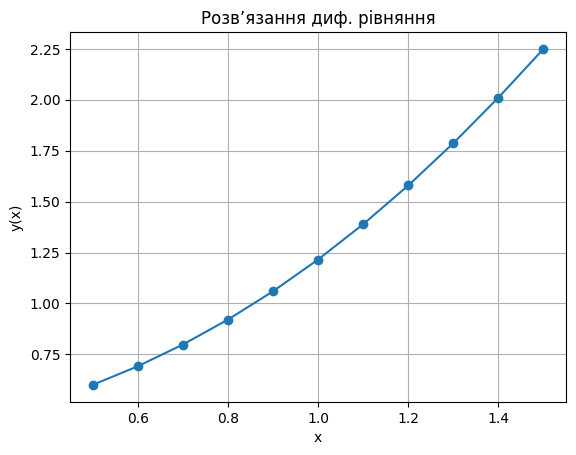

In [12]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Функція, що повертає dy/dx
def model(y, x):
    return x + np.sin(y / np.sqrt(3))

# Початкова умова
y0 = 0.6

# Значення x
a = 0.5
b = 1.5
h = 0.1
x = np.array([a + i * h for i in range(int((b - a) / h) + 1)])

# Розв'язання ODE
y = odeint(model, y0, x)

# Виведення результатів
print('x=', x)
print('y=', y.flatten())  # Перетворення в одновимірний масив для виводу

# Побудова графіка результатів
plt.plot(x, y, marker='o')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Розв’язання диф. рівняння')
plt.grid()
plt.show()


#Використання scipy.integrate.solve_ivp
Функція solve_ivp є більш сучасним і гнучким способом розв'язання ODE, ніж odeint. Вона також дозволяє використовувати різні методи інтегрування.

x= [0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5]
y= [0.6        0.69134569 0.79783481 0.92025947 1.05931652 1.21544859
 1.38884411 1.57943729 1.78690814 2.01068247 2.24982463]


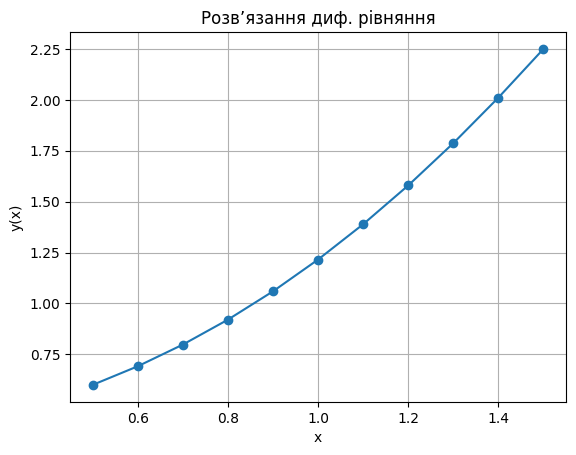

In [15]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Функція, що повертає dy/dx
def model(x, y):
    return x + np.sin(y / np.sqrt(3))

# Початкова умова
y0 = [0.6]  # Потрібно передати як список

# Межі інтегрування та крок
a = 0.5
b = 1.5
h = 0.1
x = np.array([a + i * h for i in range(int((b - a)/h) + 1)])

# Розв'язання ODE
sol = solve_ivp(model, [x[0], x[-1]], y0, t_eval=x)

# Виведення результатів
print('x=', sol.t)
print('y=', sol.y[0])

# Побудова графіка результатів
plt.plot(sol.t, sol.y[0], marker='o')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Розв’язання диф. рівняння')
plt.grid()
plt.show()
